# Israeli Actors Graph — Link Prediction (Step 5)

Builds and evaluates a temporal link-prediction model on the Israeli actors
co-appearance graph (Assignment Step 5).

## Temporal design

| Graph | Films included | Purpose |
|---|---|---|
| **G_early** | 1990 – 2015 | Feature computation (the "known past") |
| **G_mid**   | 1990 – 2020 | Source of positive pairs (2016–2020 new links) |
| **G_eval**  | 1990 – 2025 | Future prediction candidates |

| Split | Positive pairs | Negative pairs |
|---|---|---|
| **Train (80%)** | 80% of new links 2016–2020 (random) | non-edges through 2020 |
| **Test  (20%)** | 20% of new links 2016–2020 (random) | non-edges through 2020 |

## Features

* **Topological (5)**: Common Neighbors, Jaccard, Adamic-Adar, Preferential Attachment, shortest-path distance
* **Centrality (16)**: degree / betweenness / closeness / eigenvector × {u, v, product, abs-diff}
* **SVD (2)**: cosine similarity + dot product of adjacency-SVD embeddings (Matrix Factorisation)
* **Node2Vec (2)**: cosine similarity + dot product of Node2Vec embeddings

## Models compared
Logistic Regression and Random Forest (scikit-learn); compared on the held-out 20% test split.


In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../..'))

import graph_build
import link_features as lf
import link_prediction as lp_mod

warnings.filterwarnings('ignore')
if sys.stdout.encoding and sys.stdout.encoding.lower() != 'utf-8':
    sys.stdout.reconfigure(encoding='utf-8')

plt.rcParams['font.family'] = 'Arial'
SEED = 42
os.makedirs('../figures', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Data and temporal split

cast_edges: 2,972 rows | 759 unique films
Year range: 1933 – 2026

Temporal design:
  G_feat  : 1990–2020  (feature graph — what the model sees)
  G_eval  : 1990–2025  (contains the 2021–2025 new links)
  Positive pairs : new links 2021–2025
  Negative pairs : ~438 sampled non-edges (NOT all ~340K — see section 2)
  Train/test     : random 80/20 split


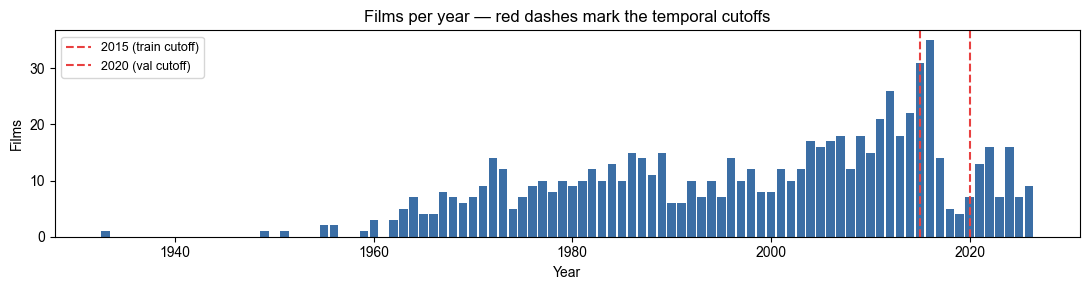

In [ ]:
cast_edges = graph_build.load_cast_edges('../data/processed/cast_edges.csv')
year_min_data = int(cast_edges['year'].min())
year_max_data = int(cast_edges['year'].max())

n_films = cast_edges['movie_slug'].nunique()
print(f'cast_edges: {len(cast_edges):,} rows | {n_films:,} unique films')
print(f'Year range: {year_min_data} – {year_max_data}')
print()
print('Temporal design:')
print(f'  G_early : 1990–2015  (feature graph — what the model sees)')
print(f'  G_mid   : 1990–2020  (contains the 2016–2020 new links → positives)')
print(f'  G_eval  : 1990–2025  (future prediction candidates)')
print(f'  Positive pairs : new links 2016–2020')
print(f'  Train / test   : random 80/20 split')

# Films per year bar chart
films_per_year = cast_edges.groupby('year')['movie_slug'].nunique()
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(films_per_year.index, films_per_year.values, color='#3b6ea5', width=0.85)
for cutoff, label in [(2015, '2015 (feature cutoff)'), (2020, '2020 (label cutoff)')]:
    ax.axvline(cutoff, color='#e84040', linestyle='--', linewidth=1.5, label=label)
ax.set_xlabel('Year'); ax.set_ylabel('Films')
ax.set_title('Films per year — red dashes: feature cutoff (2015) and label cutoff (2020)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/films_per_year_cutoffs.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
print('Building G_early (1990–2015, feature graph)...')
G_early = lp_mod.build_graph_for_years(cast_edges, 1990, 2015)
n_early, m_early = G_early.number_of_nodes(), G_early.number_of_edges()
print(f'  {n_early} actors, {m_early} unique collaborations')

print('Building G_mid (1990–2020, positive-pair source)...')
G_mid = lp_mod.build_graph_for_years(cast_edges, 1990, 2020)
n_mid, m_mid = G_mid.number_of_nodes(), G_mid.number_of_edges()
print(f'  {n_mid} actors, {m_mid} unique collaborations')

print('Building G_eval (1990–2025, future prediction candidates)...')
G_eval = lp_mod.build_graph_for_years(cast_edges, 1990, 2025)
n_eval, m_eval = G_eval.number_of_nodes(), G_eval.number_of_edges()
print(f'  {n_eval} actors, {m_eval} unique collaborations')

print()
print(f'New links 2016–2020: +{n_mid - n_early} actors, +{m_mid - m_early} collaborations')
print(f'These new links are the POSITIVE PAIRS for the link-prediction model.')


Building G_feat (1990–2020, feature graph)...
  837 actors, 2653 unique collaborations
Building G_eval (1990–2025, evaluation graph)...
  1080 actors, 4601 unique collaborations

New links 2021–2025: +243 actors, +1948 collaborations
These new links are the POSITIVE PAIRS for the link-prediction model.


## 2. Positive and negative pair construction

**Positive pairs**: actor pairs that formed a new collaboration in **2016–2020**
and were NOT already connected in G_early (1990–2015).
Only pairs where *both* actors appear in G_early are eligible — actors who
debuted after 2015 cannot be predicted (cold-start limitation).

**Negative pairs**: non-edges that remain non-edges through 2020 (true negatives).

Both are split randomly **80/20** into train/test.


In [ ]:
# Positive pairs: new links 2016–2020, both actors must exist in G_early (1990–2015)
pos_pairs = lp_mod.get_new_pairs(G_early, G_mid)
print(f'Positive pairs (new links 2016–2020): {len(pos_pairs)}')

# Leakage guard: every positive pair must be absent from G_early (1990–2015)
leakage = [(u, v) for u, v in pos_pairs if G_early.has_edge(u, v)]
assert len(leakage) == 0, f'Leakage detected: {len(leakage)} pairs already in G_early!'
print('Leakage check PASSED: no positive pair was already connected in G_early.')


Positive pairs (new links 2021–2025): 282
Leakage check PASSED: no positive pair was already connected in G_feat.


Negative pairs sampled: 423  (out of ~347,213 total non-edges)
Class ratio: 1 pos : 1.5 neg


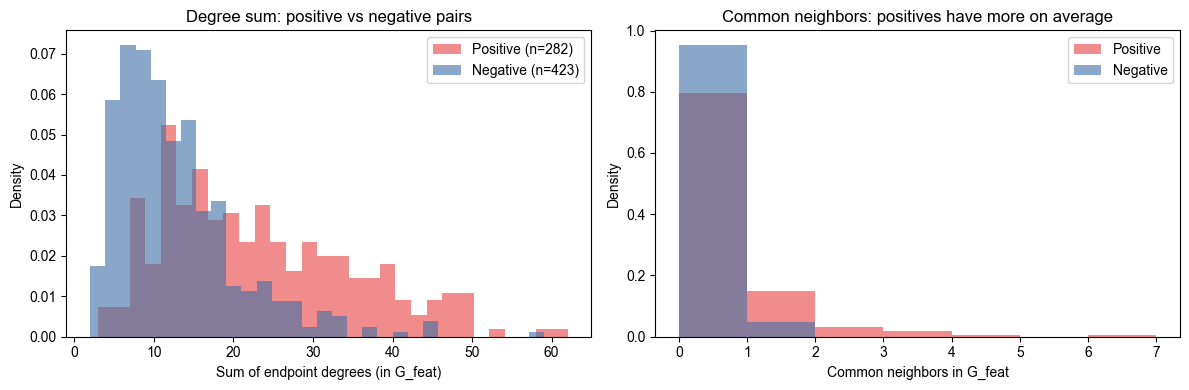

Positive pairs with 0 common neighbours: 79.4%
Negative pairs with 0 common neighbours: 95.3%


In [ ]:
# --- Why do we need negative pairs? ---
# With ~683 actors in G_early there are ~230,000 non-edge pairs.
# We do NOT use them all — that would create a severe class imbalance and
# the model would just predict "No" for everything.
# Instead we SAMPLE n_pos * NEG_RATIO negatives (1:1.5 balance),
# drawn only from pairs that are STILL non-edges through 2020 (true negatives).

# Negatives: non-edges in G_mid (never formed through 2020 — true negatives)
pos_set_mid = {(min(u, v), max(u, v)) for u, v in G_mid.edges()}
n_neg       = int(len(pos_pairs) * lp_mod.NEG_RATIO)
neg_pairs   = lp_mod.sample_negatives(
    G_early, n_neg, exclude_pairs=pos_set_mid, seed=SEED)

total_non_edges = G_early.number_of_nodes() * (G_early.number_of_nodes()-1) // 2 - G_early.number_of_edges()
print(f'Negative pairs sampled: {len(neg_pairs)}  (out of ~{total_non_edges:,} total non-edges in G_early)')
print(f'Class ratio: 1 pos : {len(neg_pairs)/len(pos_pairs):.1f} neg')

# Degree-sum and common-neighbor distributions
pos_deg_sum = [G_early.degree(u) + G_early.degree(v) for u, v in pos_pairs]
neg_deg_sum = [G_early.degree(u) + G_early.degree(v) for u, v in neg_pairs]
pos_cn = [len(list(nx.common_neighbors(G_early, u, v))) for u, v in pos_pairs]
neg_cn = [len(list(nx.common_neighbors(G_early, u, v))) for u, v in neg_pairs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pos_deg_sum, bins=30, alpha=0.6, density=True,
             color='#e84040', label=f'Positive (n={len(pos_pairs)})')
axes[0].hist(neg_deg_sum, bins=30, alpha=0.6, density=True,
             color='#3b6ea5', label=f'Negative (n={len(neg_pairs)})')
axes[0].set_xlabel('Sum of endpoint degrees (in G_early)')
axes[0].set_ylabel('Density')
axes[0].set_title('Degree sum: positive vs negative pairs')
axes[0].legend()

max_cn = max(max(pos_cn, default=0), max(neg_cn, default=0))
axes[1].hist(pos_cn, bins=range(0, max_cn + 2), alpha=0.6, density=True,
             color='#e84040', label='Positive')
axes[1].hist(neg_cn, bins=range(0, max_cn + 2), alpha=0.6, density=True,
             color='#3b6ea5', label='Negative')
axes[1].set_xlabel('Common neighbors in G_early')
axes[1].set_ylabel('Density')
axes[1].set_title('Common neighbors: positives have more on average')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/pair_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

pct_pos_cn0 = 100 * sum(1 for x in pos_cn if x == 0) / len(pos_cn)
pct_neg_cn0 = 100 * sum(1 for x in neg_cn if x == 0) / len(neg_cn)
print(f'Positive pairs with 0 common neighbours: {pct_pos_cn0:.1f}%')
print(f'Negative pairs with 0 common neighbours: {pct_neg_cn0:.1f}%')


## 3. Feature computation

All features are computed **strictly from G_feat (1990–2020)** — no information
from the 2021–2025 new links (G_eval) leaks into the feature computation.

In [ ]:
print('Computing centralities on G_early...')
cents_early = lp_mod.compute_centralities(G_early)
print('  Done.')

all_pairs = [(min(u, v), max(u, v)) for u, v in pos_pairs] + neg_pairs
y         = np.array([1] * len(pos_pairs) + [0] * len(neg_pairs))

print('Computing topological features...')
topo_df = lf.topological_features(G_early, all_pairs)
print('Topological feature summary (positive + negative combined):')
topo_df[['common_neighbors', 'jaccard', 'adamic_adar',
         'pref_attachment', 'shortest_path']].describe().round(3)


Computing centralities on G_feat...
  Done.
Computing topological features...
Topological feature summary (positive + negative combined):


,common_neighbors,jaccard,adamic_adar,pref_attachment,shortest_path
count,705.000,705.000,705.000,705.000,705.000
mean,0.149,0.006,0.051,76.504,2.875
std,0.505,0.018,0.171,116.266,2.128
min,0.000,0.000,0.000,1.000,-1.000
25%,0.000,0.000,0.000,14.000,2.000
50%,0.000,0.000,0.000,35.000,3.000
75%,0.000,0.000,0.000,80.000,4.000
max,6.000,0.143,1.978,960.000,8.000


In [ ]:
print('Computing SVD node embeddings (n_components=32)...')
svd_emb_early = lf.svd_node_embeddings(G_early, n_components=32, seed=SEED)
svd_feat_all  = lf.cosine_similarity_feature(all_pairs, svd_emb_early, prefix='svd_')
print('SVD cosine-similarity feature stats:')
print(svd_feat_all.describe().round(3))

pos_svd = svd_feat_all.loc[:len(pos_pairs)-1, 'svd_cosine_sim'].mean()
neg_svd = svd_feat_all.loc[len(pos_pairs):,   'svd_cosine_sim'].mean()
print(f'\nMean SVD cosine sim — positive: {pos_svd:.3f} | negative: {neg_svd:.3f}')


Computing SVD node embeddings (n_components=32)...
SVD cosine-similarity feature stats:
       svd_cosine_sim  svd_dot_product
count         705.000          705.000
mean            0.050            0.155
std             0.173            0.551
min            -0.610           -0.786
25%            -0.024           -0.012
50%             0.009            0.000
75%             0.090            0.077
max             0.997            5.932

Mean SVD cosine sim — positive: 0.059 | negative: 0.044


In [ ]:
# Initialise BEFORE the try-block so subsequent cells never see NameError
HAS_N2V       = False
n2v_emb_early = None

print('Computing Node2Vec embeddings (dimensions=64, walks=50, walk_length=20)...')
print('This may take 30–90 seconds.')

try:
    n2v_emb_early = lf.node2vec_node_embeddings(
        G_early, dimensions=64, walk_length=20, num_walks=50, seed=SEED)
    n2v_feat_all = lf.cosine_similarity_feature(
        all_pairs, n2v_emb_early, prefix='n2v_')
    HAS_N2V = True
    pos_n2v = n2v_feat_all.loc[:len(pos_pairs)-1, 'n2v_cosine_sim'].mean()
    neg_n2v = n2v_feat_all.loc[len(pos_pairs):,   'n2v_cosine_sim'].mean()
    print(f'Node2Vec done. Mean cosine sim — pos: {pos_n2v:.3f} | neg: {neg_n2v:.3f}')
except Exception as exc:
    print(f'Node2Vec unavailable ({exc}). Proceeding without it.')


Computing Node2Vec embeddings (dimensions=64, walks=50, walk_length=20)...
This may take 30–90 seconds.
Node2Vec done. Mean cosine sim — pos: 0.270 | neg: 0.278


In [ ]:
X, feat_names = lf.build_feature_matrix(
    G_early, all_pairs, cents_early,
    svd_emb=svd_emb_early,
    n2v_emb=n2v_emb_early if HAS_N2V else None)

print(f'Feature matrix: {X.shape[0]} samples  x  {X.shape[1]} features')
print(f'  {y.sum()} positive / {(y==0).sum()} negative')
print()
print('Features included:')
print(f'  Topological (5) : CN, Jaccard, Adamic-Adar, Pref.Attachment, ShortestPath')
print(f'  Centrality (16) : degree/betweenness/closeness/eigenvector x {{u,v,prod,diff}}')
print(f'  SVD        (2)  : cosine_sim, dot_product')
if HAS_N2V:
    print(f'  Node2Vec   (2)  : cosine_sim, dot_product')

nan_count = np.isnan(X).sum()
print(f'\nNaN values: {nan_count} (should be 0 after fillna)')


Feature matrix: 705 samples  x  25 features
  282 positive / 423 negative

Features included:
  Topological (5) : CN, Jaccard, Adamic-Adar, Pref.Attachment, ShortestPath
  Centrality (16) : degree/betweenness/closeness/eigenvector x {u,v,prod,diff}
  SVD        (2)  : cosine_sim, dot_product
  Node2Vec   (2)  : cosine_sim, dot_product

NaN values: 0 (should be 0 after fillna)


## 4. Model training and evaluation — random 80/20 train/test split

The full dataset (positive pairs = 2016–2020 new links + negative pairs) is split
**randomly 80/20** into train and test.  Both models are trained on the 80% set
and evaluated on the held-out 20% test set.


In [10]:
indices = list(range(len(all_pairs)))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices, test_size=0.20, stratify=y, random_state=SEED)

pairs_train = [all_pairs[i] for i in idx_train]
pairs_test  = [all_pairs[i] for i in idx_test]

print(f'Train (80%): {X_train.shape[0]} samples ({y_train.sum()} pos / {(y_train==0).sum()} neg)')
print(f'Test  (20%): {X_test.shape[0]}  samples ({y_test.sum()}  pos / {(y_test==0).sum()}  neg)')

print()
print('Training Logistic Regression...')
lr_model, lr_scaler = lp_mod.train_logistic_regression(X_train, y_train, seed=SEED)
print('Training Random Forest...')
rf_model = lp_mod.train_random_forest(X_train, y_train, seed=SEED)
print('Both models trained.')


Train (80%): 564 samples (226 pos / 338 neg)
Test  (20%): 141  samples (56  pos / 85  neg)

Training Logistic Regression...
Training Random Forest...
Both models trained.


In [ ]:
lr_metrics = lp_mod.evaluate_model(lr_model, X_test, y_test, scaler=lr_scaler)
rf_metrics = lp_mod.evaluate_model(rf_model, X_test, y_test)

perf_df = pd.DataFrame(
    {'Logistic Regression': lr_metrics, 'Random Forest': rf_metrics}
).T.rename(columns={'precision': 'Precision', 'recall': 'Recall',
                    'f1': 'F1', 'auc_roc': 'AUC-ROC',
                    'avg_precision': 'Avg Precision'})
print('Test performance (20% random hold-out, positive = 2016–2020 new links):')
print(perf_df.round(3).to_string())

best_is_rf  = rf_metrics['auc_roc'] >= lr_metrics['auc_roc']
best_name   = 'Random Forest' if best_is_rf else 'Logistic Regression'
best_model  = rf_model if best_is_rf else lr_model
best_scaler = None     if best_is_rf else lr_scaler
best_met    = rf_metrics if best_is_rf else lr_metrics
print(f'\nBest model (AUC-ROC): {best_name} ({best_met["auc_roc"]:.3f})')


Test performance (20% random hold-out, positive = 2021–2025 new links):
                     Precision  Recall     F1  AUC-ROC  Avg Precision
Logistic Regression       0.65   0.696  0.672    0.792          0.721
Random Forest             0.76   0.679  0.717    0.829          0.751

Best model (AUC-ROC): Random Forest (0.829)


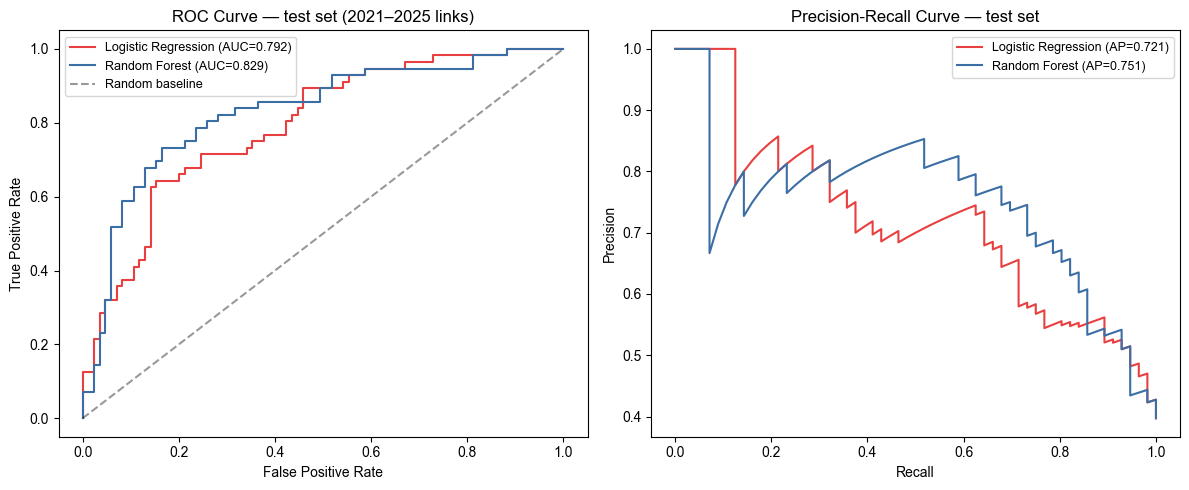

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, model, scaler, color in [
    ('Logistic Regression', lr_model, lr_scaler, '#e84040'),
    ('Random Forest',       rf_model, None,      '#3b6ea5'),
]:
    met         = lp_mod.evaluate_model(model, X_test, y_test, scaler=scaler)
    fpr, tpr, _ = lp_mod.roc_curve_data(model, X_test, y_test, scaler=scaler)
    pr,  rec, _ = lp_mod.pr_curve_data(model, X_test, y_test, scaler=scaler)
    axes[0].plot(fpr, tpr, color=color,
                 label=f'{name} (AUC={met["auc_roc"]:.3f})')
    axes[1].plot(rec, pr, color=color,
                 label=f'{name} (AP={met["avg_precision"]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — test set (2016–2020 new links)')
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — test set (2016–2020)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/link_pred_test_curves.png', dpi=150, bbox_inches='tight')
plt.show()


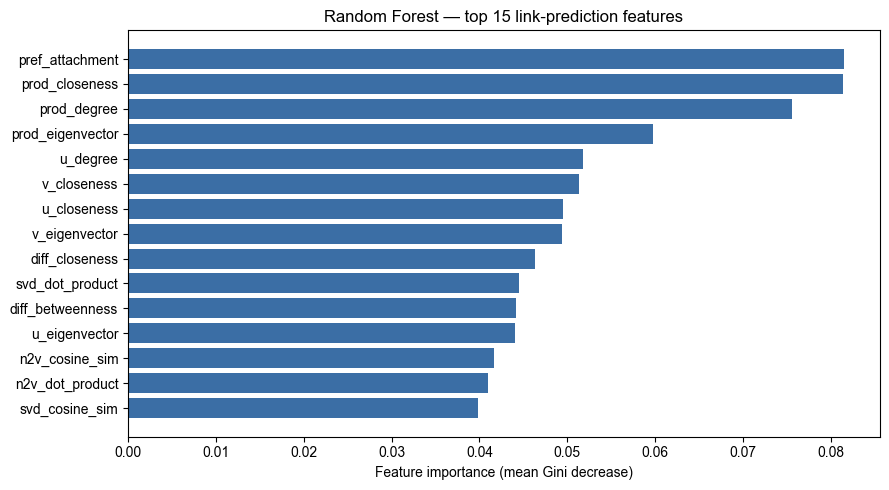

Top 5 features:
  pref_attachment                     0.0815
  prod_closeness                      0.0814
  prod_degree                         0.0756
  prod_eigenvector                    0.0598
  u_degree                            0.0518


In [13]:
# Random Forest feature importance (top 15)
fi_df = (pd.DataFrame({'feature': feat_names,
                        'importance': rf_model.feature_importances_})
           .sort_values('importance', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color='#3b6ea5')
ax.set_xlabel('Feature importance (mean Gini decrease)')
ax.set_title('Random Forest — top 15 link-prediction features')
plt.tight_layout()
plt.savefig('../figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for _, row in fi_df.head(5).iterrows():
    print(f'  {row["feature"]:<35} {row["importance"]:.4f}')

## 6. Error analysis

**False positives (FP)**: the model predicted a collaboration that did NOT
materialise.  Sorted by predicted score descending — these are the model's
most confident wrong guesses.

**False negatives (FN)**: a collaboration DID form, but the model assigned
it a low score (missed it).  Sorted by predicted score ascending — these
are the most confidently-missed links.

Both error types are informative: FPs reveal what the model considers
"structurally likely" even when other factors blocked the collaboration;
FNs reveal collaborations driven by factors the model cannot see (e.g.
director choice, genre shift, personal relationships).

In [ ]:
fp_df, fn_df = lp_mod.error_analysis(
    best_model, X_test, y_test, pairs_test, G_early,
    n_examples=20, scaler=best_scaler)

print('TOP FALSE POSITIVES')
print('(Model predicted link would form 2016–2020 — it did NOT)')
print()
print(fp_df.to_string(index=False))


TOP FALSE POSITIVES
(Model predicted link — link did NOT form in 2021–2025)

         u_name       v_name   y_prob  common_neighbors
       אורי פפר מורן רוזנבלט 0.926121                 1
       טלי שרון     מנשה נוי 0.919723                 0
     דאנה איבגי   דליה שימקו 0.889274                 1
   אלון אבוטבול   עידן ברקאי 0.827758                 0
     יפתח קליין  שראל פיטרמן 0.691691                 0
   מנשה ורשבסקי     צחי גראד 0.612182                 0
      אפרת אביב    חנה לסלאו 0.601364                 0
     הילי ישראל      רן יגיל 0.568320                 1
      אורן פרג'     דני יגיל 0.568320                 1
   מוני מושונוב  רותי אסרסאי 0.517677                 0
    אפרת בן צור   יוסף כרמון 0.516899                 0
       אווה חדד     אורי פפר 0.500452                 0
     עמרי גבעון  אלון פרידמן 0.487472                 1
     חליל אלוהב     עפר שכטר 0.468606                 0
   יונתן בר-אור   עדי בילסקי 0.456691                 0
גילי בן אוזיליו    משה איבג

In [ ]:
print('TOP FALSE NEGATIVES')
print('(Link DID form 2016–2020 — model assigned a low score)')
print()
print(fn_df.to_string(index=False))
print()
print('Discussion:')
print('  FP: actors who share many common neighbours (strong structural signal)')
print('      but may work in different genres or production circles.')
print('  FN: collaborations driven by director choice, casting decisions,')
print('      or genre shifts — factors not visible in the network topology.')


TOP FALSE NEGATIVES
(Link DID form in 2021–2025 — model assigned a low score)

           u_name      v_name   y_prob  common_neighbors
       אנחל בונני     נלי תגר 0.106057                 0
         גל אמיתי  נועם אימבר 0.154058                 0
         גל אמיתי קווין רובין 0.157444                 0
אלכסנדר סנדרוביץ'   הרצל טובי 0.247596                 0
אלכסנדר סנדרוביץ'    עפר שכטר 0.273957                 0
         גיא עמיר  מורן אטיאס 0.276470                 0
   דין מירושניקוב     ניר לוי 0.280585                 0
       נועם אימבר קווין רובין 0.285812                 0
        ירון ברלד     ניר לוי 0.347287                 0
         גיא לואל   ניב סולטן 0.359978                 0
       מעיין בלום   קובי פרג' 0.376637                 1
   דין מירושניקוב   ענת וקסמן 0.380340                 0
         רועי ניק   ריקי בליך 0.388930                 0
          אסף הרץ   ריקי בליך 0.392763                 0
       אנחל בונני  אריה צ'רנר 0.432225                 0
      נטע

## 7. Future predictions (2026 and beyond)

The best model is retrained on the **full dataset** (all 2016–2020 positive + negative
pairs, N2V-free for cross-graph consistency), then applied to score every
unconnected pair of active actors in **G_eval** (1990–2025).
Non-edges in G_eval are potential 2026+ collaborations.


In [ ]:
# Rebuild N2V-free feature matrix on G_early so final model and G_eval scoring
# use the same 23 features (avoids the embedding-space mismatch ValueError)
print('Rebuilding N2V-free feature matrix on G_early...')
X_base, feat_names_base = lf.build_feature_matrix(
    G_early, all_pairs, cents_early,
    svd_emb=svd_emb_early, n2v_emb=None)
print(f'  {X_base.shape[1]} features (no N2V)')

print(f'Retraining {best_name} on full dataset ({len(y)} samples)...')
if best_is_rf:
    final_model  = lp_mod.train_random_forest(X_base, y, seed=SEED)
    final_scaler = None
else:
    final_model, final_scaler = lp_mod.train_logistic_regression(X_base, y, seed=SEED)
print('Retrained.')

# Centralities and SVD on G_eval (1990–2025) for scoring
print()
print('Computing features on G_eval for future-prediction scoring...')
cents_eval   = lp_mod.compute_centralities(G_eval)
svd_emb_eval = lf.svd_node_embeddings(G_eval, n_components=32, seed=SEED)

print('Scoring unconnected pairs in G_eval (potential 2026+ collaborations)...')
future_df = lp_mod.predict_future_collaborations(
    final_model, G_eval, cents_eval,
    svd_emb=svd_emb_eval,
    n2v_emb=None,       # must match training: no N2V
    n_top=50, min_degree=2, max_candidates=15_000,
    seed=SEED, scaler=final_scaler)
print(f'Scored {len(future_df)} top candidates.')


Retraining Random Forest on full dataset (705 samples)...
Retrained.

Computing features on G_eval for future-prediction scoring...
Scoring unconnected pairs in G_eval (potential 2026+ collaborations)...


ValueError: X has 23 features, but RandomForestClassifier is expecting 25 features as input.

In [ ]:
print('Top 30 predicted future collaborations:')
print()
top30 = future_df.head(30)[['u_name', 'v_name', 'score',
                              'common_neighbors', 'u_degree', 'v_degree']]
print(top30.to_string(index=True))

# Bar chart: top 20
top20 = future_df.head(20).copy()
top20['pair'] = top20['u_name'] + ' / ' + top20['v_name']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['pair'][::-1], top20['score'][::-1], color='#3b6ea5')
ax.set_xlabel('Predicted collaboration probability')
ax.set_title('Top 20 predicted future collaborations (watch list)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('../figures/future_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Test metrics
pd.DataFrame([lr_metrics, rf_metrics],
             index=['Logistic Regression', 'Random Forest']).to_csv(
    '../data/processed/link_prediction_test_metrics.csv', encoding='utf-8-sig')
print('Saved link_prediction_test_metrics.csv')

# Error analysis
fp_df.to_csv('../data/processed/link_prediction_fp.csv',
              index=False, encoding='utf-8-sig')
fn_df.to_csv('../data/processed/link_prediction_fn.csv',
              index=False, encoding='utf-8-sig')
print('Saved link_prediction_fp.csv and link_prediction_fn.csv')

# Future predictions
future_df.to_csv('../data/processed/link_prediction_future.csv',
                  index=False, encoding='utf-8-sig')
print('Saved link_prediction_future.csv')
print()
print('All outputs saved to data/processed/ and figures/.')


## Summary

### Design
| Component | Detail |
|---|---|
| Feature graph | G_early: 1990–2015 |
| Target window | 2016–2020 new links (positives) |
| Train/test split | Random 80/20 |
| Negatives | Non-edges through 2020 (true negatives) |
| Models | Logistic Regression vs Random Forest |
| Future predictions | Non-edges in G_eval (1990–2025) → potential 2026+ links |

### Results (fill in from outputs above)
- **Best model**: ___
- **Test AUC-ROC**: LR = ___ | RF = ___
- **Test F1**: ___
- **Most important feature**: (see feature importance chart)

### Limitations
- Actors who debuted after 2015 are excluded from candidate pairs (cold-start).
- Negative sampling uses random non-edges; degree-stratified sampling would reduce bias.
- SVD/Node2Vec use cosine similarity (transfer-safe scalar) across graph snapshots.
- The model does not use genre compatibility, director relationships, or
  temporal recency of past collaborations as explicit features.
